In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
data = pd.read_csv(r'C:\Users\Vikash\Downloads\OLA.csv')
data

,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19099,19099,08/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,740280,3
19100,19100,09/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,448370,3
19101,19101,10/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,0,2
19102,19102,11/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,200420,2


Gender
0.0    11074
1.0     7978
Name: count, dtype: int64

In [2]:
data.columns

Index(['Unnamed: 0', 'MMM-YY', 'Driver_ID', 'Age', 'Gender', 'City',
       'Education_Level', 'Income', 'Dateofjoining', 'LastWorkingDate',
       'Joining Designation', 'Grade', 'Total Business Value',
       'Quarterly Rating'],
      dtype='object')

In [3]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve
import time


In [5]:
data.head()

,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


In [6]:
data.tail()

,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
19099,19099,08/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,740280,3
19100,19100,09/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,448370,3
19101,19101,10/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,0,2
19102,19102,11/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,200420,2
19103,19103,12/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,411480,2


In [7]:
data.shape

(19104, 14)

In [8]:
#Removing the unwanted column Unnamed: 0
data.drop(['Unnamed: 0'],axis=1,inplace=True)
data

,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19099,08/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,740280,3
19100,09/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,448370,3
19101,10/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,0,2
19102,11/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,200420,2


In [9]:
data.nunique()

MMM-YY                     24
Driver_ID                2381
Age                        36
Gender                      2
City                       29
Education_Level             3
Income                   2383
Dateofjoining             869
LastWorkingDate           493
Joining Designation         5
Grade                       5
Total Business Value    10181
Quarterly Rating            4
dtype: int64

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   MMM-YY                19104 non-null  object 
 1   Driver_ID             19104 non-null  int64  
 2   Age                   19043 non-null  float64
 3   Gender                19052 non-null  float64
 4   City                  19104 non-null  object 
 5   Education_Level       19104 non-null  int64  
 6   Income                19104 non-null  int64  
 7   Dateofjoining         19104 non-null  object 
 8   LastWorkingDate       1616 non-null   object 
 9   Joining Designation   19104 non-null  int64  
 10  Grade                 19104 non-null  int64  
 11  Total Business Value  19104 non-null  int64  
 12  Quarterly Rating      19104 non-null  int64  
dtypes: float64(2), int64(7), object(4)
memory usage: 1.9+ MB


In [11]:
data["MMM-YY"] = pd.to_datetime(data["MMM-YY"])
data["Dateofjoining"] = pd.to_datetime(data["Dateofjoining"])
data["LastWorkingDate"] = pd.to_datetime(data["LastWorkingDate"])


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   MMM-YY                19104 non-null  datetime64[ns]
 1   Driver_ID             19104 non-null  int64         
 2   Age                   19043 non-null  float64       
 3   Gender                19052 non-null  float64       
 4   City                  19104 non-null  object        
 5   Education_Level       19104 non-null  int64         
 6   Income                19104 non-null  int64         
 7   Dateofjoining         19104 non-null  datetime64[ns]
 8   LastWorkingDate       1616 non-null   datetime64[ns]
 9   Joining Designation   19104 non-null  int64         
 10  Grade                 19104 non-null  int64         
 11  Total Business Value  19104 non-null  int64         
 12  Quarterly Rating      19104 non-null  int64         
dtypes: datetime64[ns

In [13]:
data.isnull().sum()

MMM-YY                      0
Driver_ID                   0
Age                        61
Gender                     52
City                        0
Education_Level             0
Income                      0
Dateofjoining               0
LastWorkingDate         17488
Joining Designation         0
Grade                       0
Total Business Value        0
Quarterly Rating            0
dtype: int64

• There are missing values found in AGE, Gender
• LastWorkingDate feature contains missing values which indicates the driver has not left the company yet.

In [14]:
num_vars = data.select_dtypes(np.number)
num_vars.columns

Index(['Driver_ID', 'Age', 'Gender', 'Education_Level', 'Income',
       'Joining Designation', 'Grade', 'Total Business Value',
       'Quarterly Rating'],
      dtype='object')

In [15]:
num_vars.drop(["Driver_ID"], axis = 1, inplace = True)


In [16]:
num_vars

,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,28.0,0.0,2,57387,1,1,2381060,2
1,28.0,0.0,2,57387,1,1,-665480,2
2,28.0,0.0,2,57387,1,1,0,2
3,31.0,0.0,2,67016,2,2,0,1
4,31.0,0.0,2,67016,2,2,0,1
...,...,...,...,...,...,...,...,...
19099,30.0,0.0,2,70254,2,2,740280,3
19100,30.0,0.0,2,70254,2,2,448370,3
19101,30.0,0.0,2,70254,2,2,0,2
19102,30.0,0.0,2,70254,2,2,200420,2


In [17]:
imputer = KNNImputer(n_neighbors=5, weights='uniform',metric='nan_euclidean')
imputer.fit(num_vars)
data_new = imputer.transform(num_vars)
data_new = pd.DataFrame(data_new)
data_new.columns = num_vars.columns

data_new

,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,28.0,0.0,2.0,57387.0,1.0,1.0,2381060.0,2.0
1,28.0,0.0,2.0,57387.0,1.0,1.0,-665480.0,2.0
2,28.0,0.0,2.0,57387.0,1.0,1.0,0.0,2.0
3,31.0,0.0,2.0,67016.0,2.0,2.0,0.0,1.0
4,31.0,0.0,2.0,67016.0,2.0,2.0,0.0,1.0
...,...,...,...,...,...,...,...,...
19099,30.0,0.0,2.0,70254.0,2.0,2.0,740280.0,3.0
19100,30.0,0.0,2.0,70254.0,2.0,2.0,448370.0,3.0
19101,30.0,0.0,2.0,70254.0,2.0,2.0,0.0,2.0
19102,30.0,0.0,2.0,70254.0,2.0,2.0,200420.0,2.0


In [18]:
data_new.isnull().sum()


Age                     0
Gender                  0
Education_Level         0
Income                  0
Joining Designation     0
Grade                   0
Total Business Value    0
Quarterly Rating        0
dtype: int64

We have successfully imputed the missing values using KNNImputer

In [19]:
data_new.nunique()

Age                        70
Gender                      6
Education_Level             3
Income                   2383
Joining Designation         5
Grade                       5
Total Business Value    10181
Quarterly Rating            4
dtype: int64

In [20]:
resultant_columns = list(set(data.columns).difference(set(num_vars)))
resultant_columns

['City', 'MMM-YY', 'Dateofjoining', 'LastWorkingDate', 'Driver_ID']

In [21]:
new_df = pd.concat([data_new, data[resultant_columns]], axis=1)
new_df.shape


(19104, 13)

In [22]:
new_df.head()


,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating,City,MMM-YY,Dateofjoining,LastWorkingDate,Driver_ID
0,28.0,0.0,2.0,57387.0,1.0,1.0,2381060.0,2.0,C23,2019-01-01,2018-12-24,NaT,1
1,28.0,0.0,2.0,57387.0,1.0,1.0,-665480.0,2.0,C23,2019-02-01,2018-12-24,NaT,1
2,28.0,0.0,2.0,57387.0,1.0,1.0,0.0,2.0,C23,2019-03-01,2018-12-24,2019-03-11,1
3,31.0,0.0,2.0,67016.0,2.0,2.0,0.0,1.0,C7,2020-11-01,2020-11-06,NaT,2
4,31.0,0.0,2.0,67016.0,2.0,2.0,0.0,1.0,C7,2020-12-01,2020-11-06,NaT,2


Data Preprocessing

Feature Engineering


In [24]:
agg_functions = {
 "Age": "max",
 "Gender": "first",
 "Education_Level": "last",
 "Income": "last",
 "Joining Designation": "last",
 "Grade": "last",
 "Total Business Value": "sum",
 "Quarterly Rating": "last",
 "LastWorkingDate": "last",
 "City": "first",
 "Dateofjoining": "last"
}
processed_df = new_df.groupby(["Driver_ID", "MMM-YY"]).aggregate(agg_functions).sort_index(ascending = [True, True])
processed_df.head()

Age  Gender  Education_Level   Income  \
Driver_ID MMM-YY                                               
1         2019-01-01  28.0     0.0              2.0  57387.0   
          2019-02-01  28.0     0.0              2.0  57387.0   
          2019-03-01  28.0     0.0              2.0  57387.0   
2         2020-11-01  31.0     0.0              2.0  67016.0   
          2020-12-01  31.0     0.0              2.0  67016.0   

                      Joining Designation  Grade  Total Business Value  \
Driver_ID MMM-YY                                                         
1         2019-01-01                  1.0    1.0             2381060.0   
          2019-02-01                  1.0    1.0             -665480.0   
          2019-03-01                  1.0    1.0                   0.0   
2         2020-11-01                  2.0    2.0                   0.0   
          2020-12-01                  2.0    2.0                   0.0   

                      Quarterly Rating LastWorkingDate City Dateofjoining  
Driver_ID MMM-YY                                                           
1         2019-01-01               2.0             NaT  C23    2018-12-24  
          2019-02-01               2.0             NaT  C23    2018-12-24  
          2019-03-01               2.0      2019-03-11  C23    2018-12-24  
2         2020-11-01               1.0             NaT   C7    2020-11-06  
          2020-12-01               1.0             NaT   C7    2020-11-06

In [26]:
processed_df.columns


Index(['Age', 'Gender', 'Education_Level', 'Income', 'Joining Designation',
       'Grade', 'Total Business Value', 'Quarterly Rating', 'LastWorkingDate',
       'City', 'Dateofjoining'],
      dtype='object')

In [39]:
processed_df.shape

(19104, 11)

In [29]:
final_data = pd.DataFrame()
final_data["Driver_ID"] = new_df["Driver_ID"].unique()
final_data['Age'] =list(processed_df.groupby('Driver_ID',axis=0).max('MMM-YY')['Age'])
final_data['Gender'] =list(processed_df.groupby('Driver_ID').agg({'Gender':'last'})
['Gender'])
final_data['City'] =list(processed_df.groupby('Driver_ID').agg({'City':'last'})['City'])
final_data['Education'] =list(processed_df.groupby('Driver_ID').agg({'Education_Level':'last'})['Education_Level'])
final_data['Income'] =list(processed_df.groupby('Driver_ID').agg({'Income':'last'})['Income'])
final_data['Joining_Designation'] =list(processed_df.groupby('Driver_ID').agg({'Joining Designation':'last'})['Joining Designation'])
final_data['Grade'] =list(processed_df.groupby('Driver_ID').agg({'Grade':'last'})['Grade'])
final_data['Total_Business_Value'] =list(processed_df.groupby('Driver_ID',axis=0).sum('Total BusinessValue')['Total Business Value'])
final_data['Last_Quarterly_Rating'] =list(processed_df.groupby('Driver_ID').agg({'Quarterly Rating':'last'})['Quarterly Rating'])
final_data.head() 


,Driver_ID,Age,Gender,City,Education,Income,Joining_Designation,Grade,Total_Business_Value,Last_Quarterly_Rating
0,1,28.0,0.0,C23,2.0,57387.0,1.0,1.0,1715580.0,2.0
1,2,31.0,0.0,C7,2.0,67016.0,2.0,2.0,0.0,1.0
2,4,43.0,0.0,C13,2.0,65603.0,2.0,2.0,350000.0,1.0
3,5,29.0,0.0,C9,0.0,46368.0,1.0,1.0,120360.0,1.0
4,6,31.0,1.0,C11,1.0,78728.0,3.0,3.0,1265000.0,2.0


In [34]:
final_data.shape

(2381, 10)

In [35]:
first_quarter = processed_df.groupby(["Driver_ID"]).agg({"Quarterly Rating": "first"})
last_quarter = processed_df.groupby(["Driver_ID"]).agg({"Quarterly Rating": "last"})
qr = (last_quarter["Quarterly Rating"] > first_quarter["Quarterly Rating"]).reset_index()
empid = qr[qr["Quarterly Rating"] == True]["Driver_ID"]
qrl = []
for i in final_data["Driver_ID"]:
    if i in empid.values:
        qrl.append(1)
    else:
        qrl.append(0)
final_data["Quarterly_Rating_Increased"] = qrl
final_data.head()

,Driver_ID,Age,Gender,City,Education,Income,Joining_Designation,Grade,Total_Business_Value,Last_Quarterly_Rating,Quarterly_Rating_Increased
0,1,28.0,0.0,C23,2.0,57387.0,1.0,1.0,1715580.0,2.0,0
1,2,31.0,0.0,C7,2.0,67016.0,2.0,2.0,0.0,1.0,0
2,4,43.0,0.0,C13,2.0,65603.0,2.0,2.0,350000.0,1.0,0
3,5,29.0,0.0,C9,0.0,46368.0,1.0,1.0,120360.0,1.0,0
4,6,31.0,1.0,C11,1.0,78728.0,3.0,3.0,1265000.0,2.0,1


In [36]:
lwd = (processed_df.groupby(["Driver_ID"]).agg({"LastWorkingDate":"last"})["LastWorkingDate"].isna()).reset_index()
lwrid = lwd[lwd["LastWorkingDate"] == True]["Driver_ID"]
target = []
for i in final_data["Driver_ID"]:
 if i in lwrid.values:
     target.append(0)
 else:
     target.append(1)
final_data["target"] = target
final_data.head()


,Driver_ID,Age,Gender,City,Education,Income,Joining_Designation,Grade,Total_Business_Value,Last_Quarterly_Rating,Quarterly_Rating_Increased,target
0,1,28.0,0.0,C23,2.0,57387.0,1.0,1.0,1715580.0,2.0,0,1
1,2,31.0,0.0,C7,2.0,67016.0,2.0,2.0,0.0,1.0,0,0
2,4,43.0,0.0,C13,2.0,65603.0,2.0,2.0,350000.0,1.0,0,1
3,5,29.0,0.0,C9,0.0,46368.0,1.0,1.0,120360.0,1.0,0,1
4,6,31.0,1.0,C11,1.0,78728.0,3.0,3.0,1265000.0,2.0,1,0


In [56]:
lwd = (processed_df.groupby(["Driver_ID"]).agg({"LastWorkingDate":"last"})["LastWorkingDate"].isna()).reset_index()
lwrid = lwd[lwd["LastWorkingDate"] == True]["Driver_ID"]
target = []
for i in final_data["Driver_ID"]:
 if i in lwrid.values:
     target.append(0)
 else:
     target.append(1)
final_data["target"] = target
final_data.head()



,Driver_ID,Age,Gender,City,Education,Income,Joining_Designation,Grade,Total_Business_Value,Last_Quarterly_Rating,Quarterly_Rating_Increased,target
0,1,28.0,0.0,C23,2.0,57387.0,1.0,1.0,1715580.0,2.0,0,1
1,2,31.0,0.0,C7,2.0,67016.0,2.0,2.0,0.0,1.0,0,0
2,4,43.0,0.0,C13,2.0,65603.0,2.0,2.0,350000.0,1.0,0,1
3,5,29.0,0.0,C9,0.0,46368.0,1.0,1.0,120360.0,1.0,0,1
4,6,31.0,1.0,C11,1.0,78728.0,3.0,3.0,1265000.0,2.0,1,0


In [60]:
mrf = processed_df.groupby(["Driver_ID"]).agg({"Income": "first"})
mrl = processed_df.groupby(["Driver_ID"]).agg({"Income": "last"})
mr = (mrl["Income"] > mrf["Income"]).reset_index()
empid = mr[mr["Income"] == True]["Driver_ID"]
income = []
for i in final_data["Driver_ID"]:
 if i in empid.values:
     income.append(1)
 else:
     income.append(0)
final_data["Salary_Increased"] = income
final_data.head()


,Driver_ID,Age,Gender,City,Education,Income,Joining_Designation,Grade,Total_Business_Value,Last_Quarterly_Rating,Quarterly_Rating_Increased,target,Salary_Increased
0,1,28.0,0.0,C23,2.0,57387.0,1.0,1.0,1715580.0,2.0,0,1,0
1,2,31.0,0.0,C7,2.0,67016.0,2.0,2.0,0.0,1.0,0,0,0
2,4,43.0,0.0,C13,2.0,65603.0,2.0,2.0,350000.0,1.0,0,1,0
3,5,29.0,0.0,C9,0.0,46368.0,1.0,1.0,120360.0,1.0,0,1,0
4,6,31.0,1.0,C11,1.0,78728.0,3.0,3.0,1265000.0,2.0,1,0,0


In [65]:
final_data["Salary_Increased"].value_counts()

Salary_Increased
0    2338
1      43
Name: count, dtype: int64

• Around 1.8% drivers income have been increased.

In [67]:
final_data.describe().T


,count,mean,std,min,25%,50%,75%,max
Driver_ID,2381.0,1.397559e+03,8.061616e+02,1.0,695.0,1400.0,2100.0,2788.0
Age,2381.0,3.377018e+01,5.933265e+00,21.0,30.0,33.0,37.0,58.0
Gender,2381.0,4.105838e-01,4.914963e-01,0.0,0.0,0.0,1.0,1.0
Education,2381.0,1.007560e+00,8.162900e-01,0.0,0.0,1.0,2.0,2.0
Income,2381.0,5.933416e+04,2.838367e+04,10747.0,39104.0,55315.0,75986.0,188418.0
Joining_Designation,2381.0,1.820244e+00,8.414334e-01,1.0,1.0,2.0,2.0,5.0
Grade,2381.0,2.096598e+00,9.415218e-01,1.0,1.0,2.0,3.0,5.0
Total_Business_Value,2381.0,4.586742e+06,9.127115e+06,-1385530.0,0.0,817680.0,4173650.0,95331060.0
Last_Quarterly_Rating,2381.0,1.427971e+00,8.098389e-01,1.0,1.0,1.0,2.0,4.0
Quarterly_Rating_Increased,2381.0,1.503570e-01,3.574961e-01,0.0,0.0,0.0,0.0,1.0


• There are total of 2381 different drivers data.

• Age of drivers range from 21years to 58years.

• 75% drivers monthly income is <= 75986.

• 75% drivers acquired 4173650 as total business values.

In [68]:
final_data.describe(include = 'object')


,City
count,2381
unique,29
top,C20
freq,152


• Majority of drivers are coming from C20 city

In [79]:
final_data["Gender"].value_counts()


Gender
0.0    1400
1.0     975
0.6       3
0.2       2
0.4       1
Name: count, dtype: int64

• Majority of drivers are male


In [81]:
final_data["Education"].value_counts()

Education
2.0    802
1.0    795
0.0    784
Name: count, dtype: int64

• Majority of drivers have completed their graduation.

In [82]:
final_data["target"].value_counts()


target
1    1616
0     765
Name: count, dtype: int64

Out of 2381 drivers 1616 have left the comp

In [84]:
n =['Gender','Education','Joining_Designation','Grade','Last_Quarterly_Rating','Quarterly_Rating_Increased']
for i in n:

    print("------------------------------------------------------------")
    print(final_data[i].value_counts(normalize=True) * 100)


------------------------------------------------------------
Gender
0.0    58.798824
1.0    40.949181
0.6     0.125997
0.2     0.083998
0.4     0.041999
Name: proportion, dtype: float64
------------------------------------------------------------
Education
2.0    33.683326
1.0    33.389332
0.0    32.927341
Name: proportion, dtype: float64
------------------------------------------------------------
Joining_Designation
1.0    43.091138
2.0    34.229315
3.0    20.705586
4.0     1.511970
5.0     0.461991
Name: proportion, dtype: float64
------------------------------------------------------------
Grade
2.0    35.909282
1.0    31.121378
3.0    26.165477
4.0     5.795884
5.0     1.007980
Name: proportion, dtype: float64
------------------------------------------------------------
Last_Quarterly_Rating
1.0    73.246535
2.0    15.203696
3.0     7.055859
4.0     4.493910
Name: proportion, dtype: float64
------------------------------------------------------------
Quarterly_Rating_Increased
0  

• 58% of drivers are male while female constitutes around 40%

• 33% of drivers have completed graduation and 12+ education

• 43% of drivers have 1 as joining_designation

• Around 36% of drivers graded as 2

• Around 73% of drivers rated as 1 on last quarter

• Only 15% of drivers rating has been increased on quarterly

<Axes: xlabel='Salary_Increased', ylabel='count'>

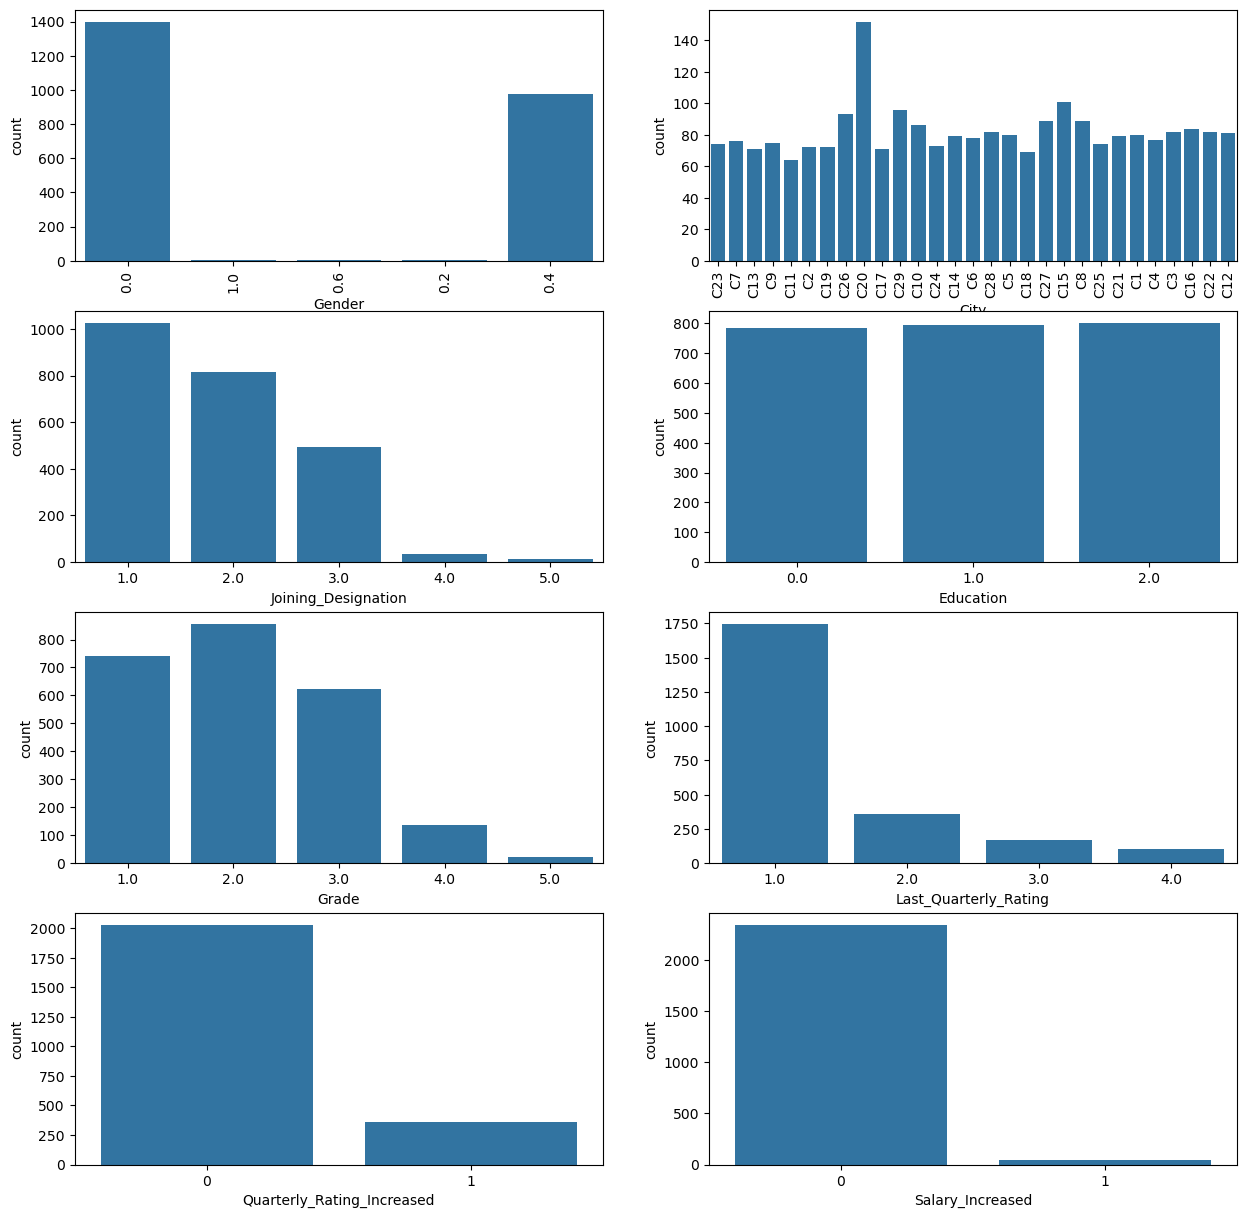

In [87]:
plt.figure(figsize=(15, 15))
plt.subplot(421)
sns.countplot(data=final_data, x="Gender")
final_data["Gender"].value_counts(normalize=True).plot.bar('Gender')
plt.subplot(422)
sns.countplot(data=final_data, x="City")
plt.xticks(rotation="vertical")
plt.subplot(423)
sns.countplot(data=final_data, x="Joining_Designation")
plt.subplot(424)
sns.countplot(data=final_data, x="Education")
plt.subplot(425)
sns.countplot(data=final_data, x="Grade")
plt.subplot(426)
sns.countplot(data=final_data, x="Last_Quarterly_Rating")
plt.subplot(427)
sns.countplot(data=final_data, x="Quarterly_Rating_Increased")
plt.subplot(428)
sns.countplot(data=final_data, x="Salary_Increased")


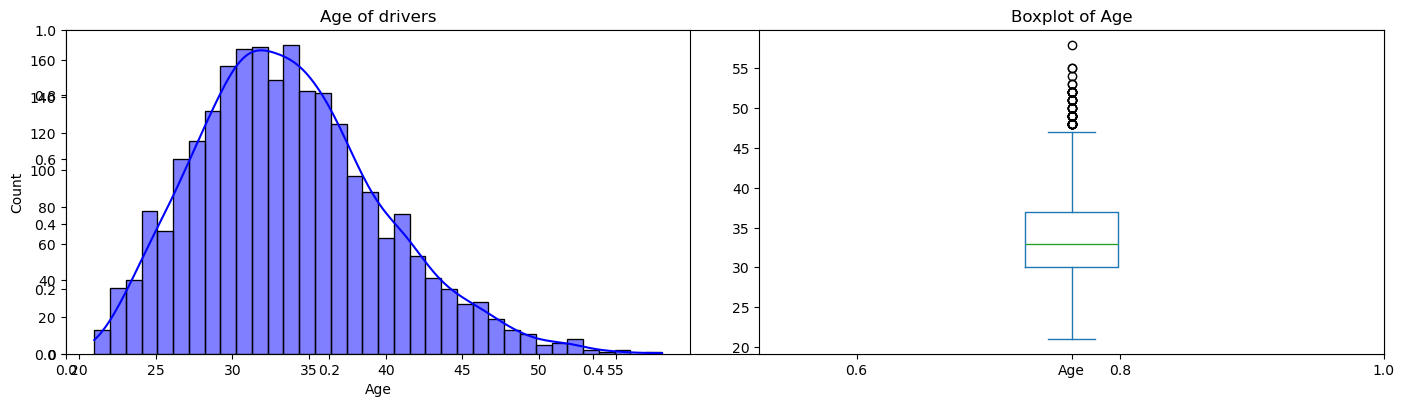

In [88]:
plt.subplots(figsize=(15,5))
plt.subplot(121)
sns.histplot(final_data['Age'],color='blue', kde=True)
plt.title("Age of drivers")
plt.subplot(122)
final_data['Age'].plot.box(title='Boxplot of Age')
plt.tight_layout(pad=3)


• The age distribution of the drivers is left-skewed. This means that there are more younger drivers than older drivers. The median age is around 30 years old.

• There is a wide range of ages in the dataset, from 20 to 55 years old.

• There are a few outliers in the data, which are drivers who are either much younger or
much older than the majority of the drivers.

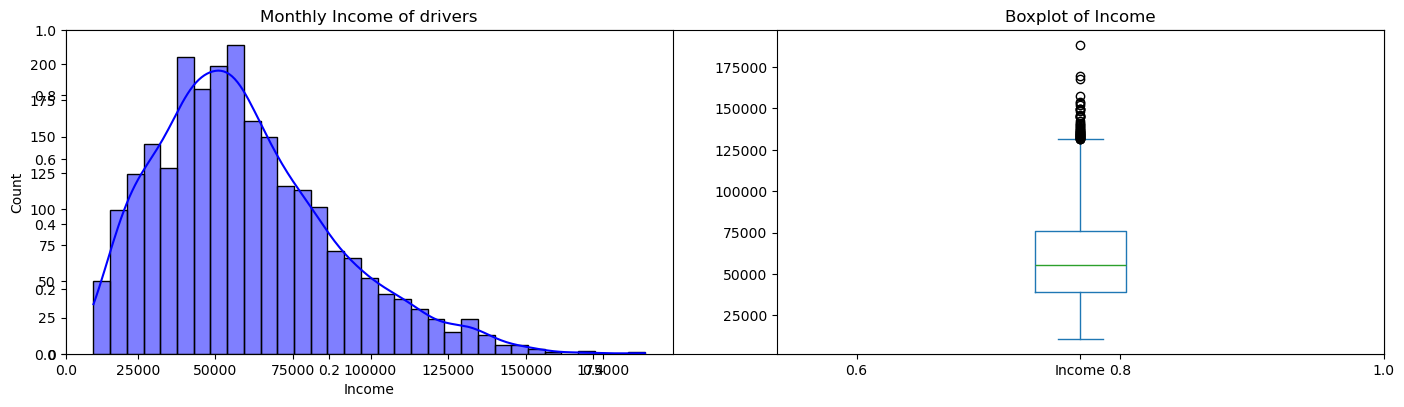

In [89]:
plt.subplots(figsize=(15,5))
plt.subplot(121)
sns.histplot(final_data['Income'],color='blue', kde=True)
plt.title("Monthly Income of drivers")
plt.subplot(122)
final_data['Income'].plot.box(title='Boxplot of Income')
plt.tight_layout(pad=3)


Insights
 • The distribution of monthly income skewed on right which might indicate the outliers in the data


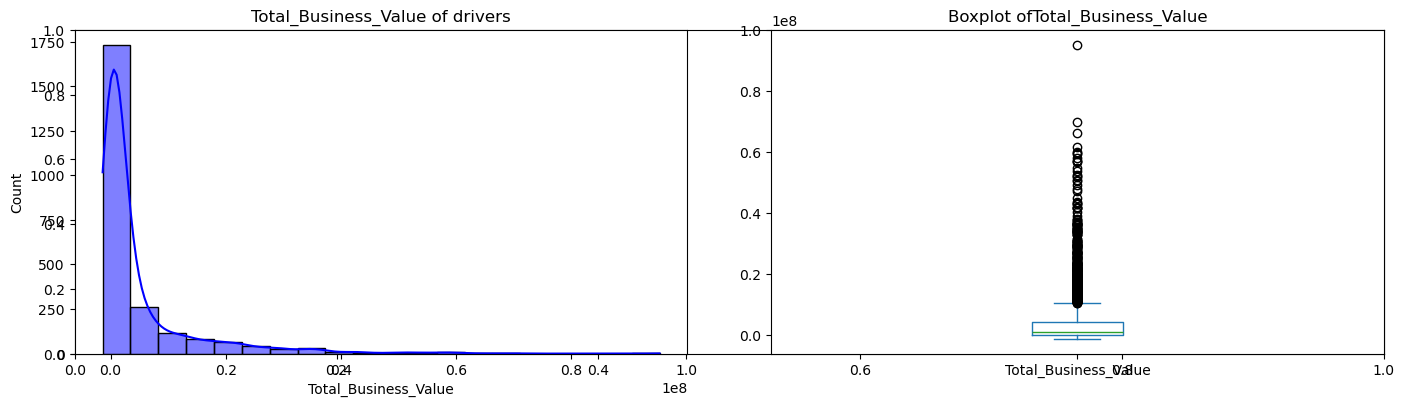

In [91]:
plt.subplots(figsize=(15,5))
plt.subplot(121)
sns.histplot(final_data['Total_Business_Value'],color='blue',
kde=True, bins=20)
plt.title("Total_Business_Value of drivers")
plt.subplot(122)
final_data['Total_Business_Value'].plot.box(title='Boxplot ofTotal_Business_Value')
plt.tight_layout(pad=3)

Insights

• The distribution of total business value highly skewed on right which might indicate the
outliers in the data

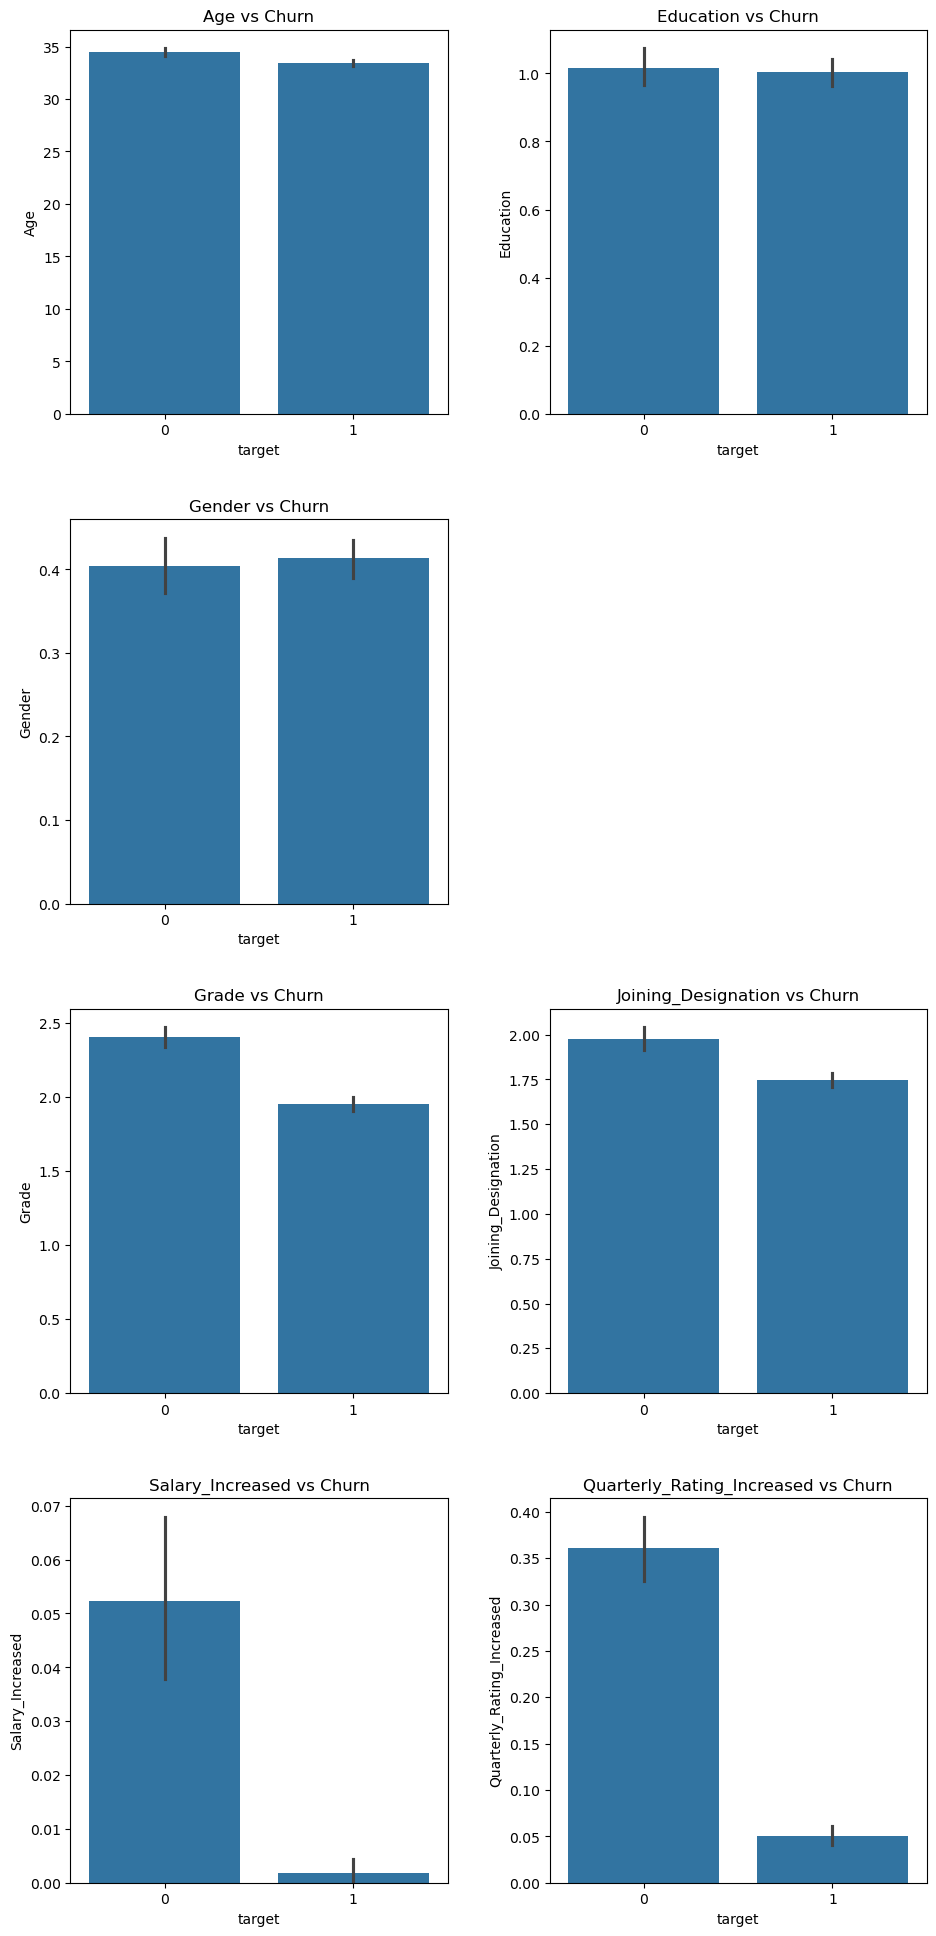

In [93]:
plt.figure(figsize=(10,20))
plt.subplot(421)
sns.barplot(data=final_data, x="target", y="Age")
plt.title("Age vs Churn")
plt.subplot(422)
sns.barplot(data=final_data, x="target", y="Education")
plt.title("Education vs Churn")
plt.subplot(423)
sns.barplot(data=final_data, x="target", y="Gender")
plt.title("Gender vs Churn")
plt.subplot(425)
sns.barplot(data=final_data, x="target", y="Grade")
plt.title("Grade vs Churn")
plt.subplot(426)
sns.barplot(data=final_data, x="target", y="Joining_Designation")
plt.title("Joining_Designation vs Churn")
plt.subplot(427)
sns.barplot(data=final_data, x="target", y="Salary_Increased")
plt.title("Salary_Increased vs Churn")
plt.subplot(428)
sns.barplot(data=final_data, x="target",
y="Quarterly_Rating_Increased")
plt.title("Quarterly_Rating_Increased vs Churn")
plt.tight_layout(pad=3)

• The proportion of Age, gender and education is more or less the same for both the employees who left the organization and those who did not leave.

• The employees who have their grade as 3 or 4 at the time of joining are less likely to leave the organization.

• The employees whose quarterly rating has increased are less likely to leave the organization.

• The employees whose monthly salary has not increased are more likely to leave the organization

Correlation Analysis

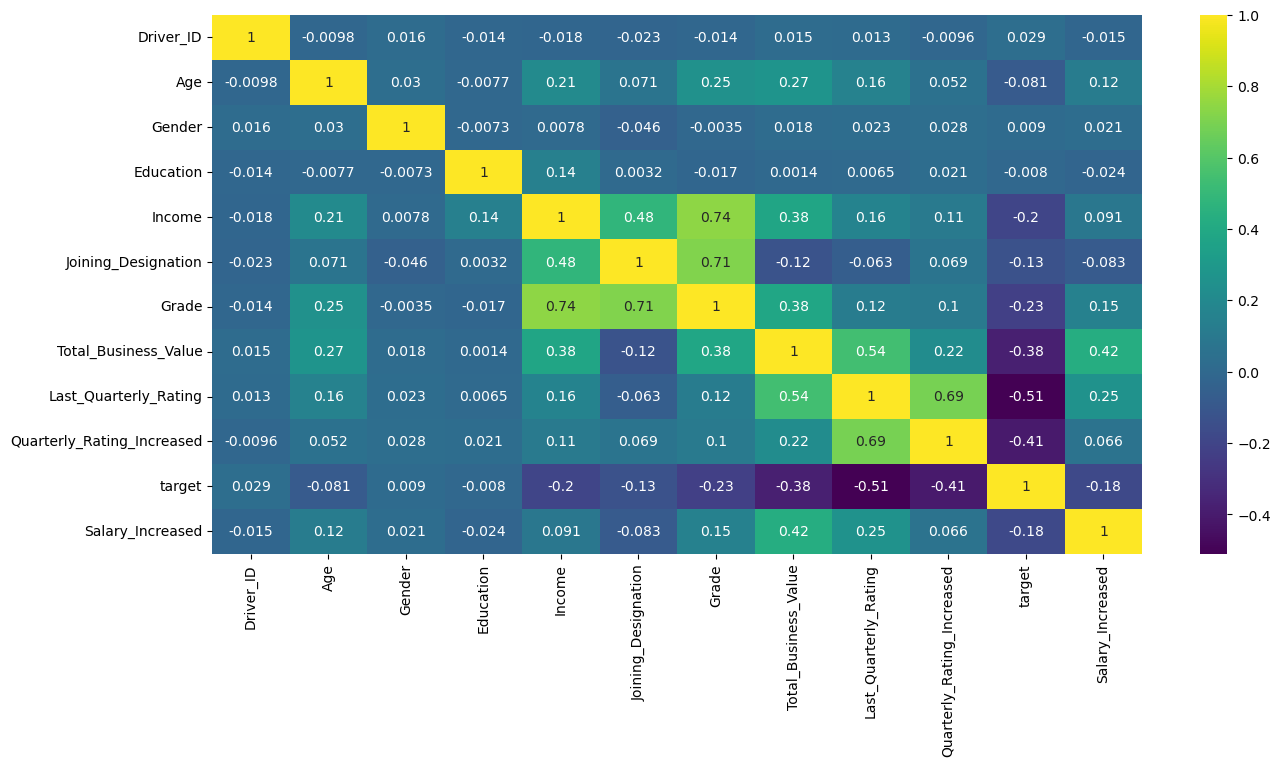

In [96]:
numeric_df = final_data.select_dtypes(include=['number'])

plt.figure(figsize=(15,7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="viridis")
plt.show()



• Age is positively correlated with grade, total business value, and last quarterly rating.
This means that older drivers tend to have higher grades, total business value, and last
quarterly ratings.

• Gender is positively correlated with joining designation and grade. This means that
female drivers are more likely to have higher joining designations and grades.

• Education is positively correlated with income and target. This means that drivers with
more education tend to have higher incomes and targets.


In [97]:
final_data

,Driver_ID,Age,Gender,City,Education,Income,Joining_Designation,Grade,Total_Business_Value,Last_Quarterly_Rating,Quarterly_Rating_Increased,target,Salary_Increased
0,1,28.0,0.0,C23,2.0,57387.0,1.0,1.0,1715580.0,2.0,0,1,0
1,2,31.0,0.0,C7,2.0,67016.0,2.0,2.0,0.0,1.0,0,0,0
2,4,43.0,0.0,C13,2.0,65603.0,2.0,2.0,350000.0,1.0,0,1,0
3,5,29.0,0.0,C9,0.0,46368.0,1.0,1.0,120360.0,1.0,0,1,0
4,6,31.0,1.0,C11,1.0,78728.0,3.0,3.0,1265000.0,2.0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2376,2784,34.0,0.0,C24,0.0,82815.0,2.0,3.0,21748820.0,4.0,1,0,0
2377,2785,34.0,1.0,C9,0.0,12105.0,1.0,1.0,0.0,1.0,0,1,0
2378,2786,45.0,0.0,C19,0.0,35370.0,2.0,2.0,2815090.0,1.0,0,1,0
2379,2787,28.0,1.0,C20,2.0,69498.0,1.0,1.0,977830.0,1.0,0,1,0


In [98]:
final_data = pd.concat([final_data, final_data['City']], axis=1)
final_data

,Driver_ID,Age,Gender,City,Education,Income,Joining_Designation,Grade,Total_Business_Value,Last_Quarterly_Rating,Quarterly_Rating_Increased,target,Salary_Increased,City
0,1,28.0,0.0,C23,2.0,57387.0,1.0,1.0,1715580.0,2.0,0,1,0,C23
1,2,31.0,0.0,C7,2.0,67016.0,2.0,2.0,0.0,1.0,0,0,0,C7
2,4,43.0,0.0,C13,2.0,65603.0,2.0,2.0,350000.0,1.0,0,1,0,C13
3,5,29.0,0.0,C9,0.0,46368.0,1.0,1.0,120360.0,1.0,0,1,0,C9
4,6,31.0,1.0,C11,1.0,78728.0,3.0,3.0,1265000.0,2.0,1,0,0,C11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2376,2784,34.0,0.0,C24,0.0,82815.0,2.0,3.0,21748820.0,4.0,1,0,0,C24
2377,2785,34.0,1.0,C9,0.0,12105.0,1.0,1.0,0.0,1.0,0,1,0,C9
2378,2786,45.0,0.0,C19,0.0,35370.0,2.0,2.0,2815090.0,1.0,0,1,0,C19
2379,2787,28.0,1.0,C20,2.0,69498.0,1.0,1.0,977830.0,1.0,0,1,0,C20


In [103]:
X = final_data.drop(["Driver_ID", "target", "City"], axis = 1)
X_cols = X.columns
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X = pd.DataFrame(X)
X.columns = X_cols

X

,Age,Gender,Education,Income,Joining_Designation,Grade,Total_Business_Value,Last_Quarterly_Rating,Quarterly_Rating_Increased,Salary_Increased
0,0.189189,0.0,1.0,0.262508,0.00,0.00,0.032064,0.333333,0.0,0.0
1,0.270270,0.0,1.0,0.316703,0.25,0.25,0.014326,0.000000,0.0,0.0
2,0.594595,0.0,1.0,0.308750,0.25,0.25,0.017944,0.000000,0.0,0.0
3,0.216216,0.0,0.0,0.200489,0.00,0.00,0.015570,0.000000,0.0,0.0
4,0.270270,1.0,0.5,0.382623,0.50,0.50,0.027405,0.333333,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...
2376,0.351351,0.0,0.0,0.405626,0.25,0.50,0.239197,1.000000,1.0,0.0
2377,0.351351,1.0,0.0,0.007643,0.00,0.00,0.014326,0.000000,0.0,0.0
2378,0.648649,0.0,0.0,0.138588,0.25,0.25,0.043432,0.000000,0.0,0.0
2379,0.189189,1.0,1.0,0.330673,0.00,0.00,0.024436,0.000000,0.0,0.0


In [104]:
y = final_data["target"]

In [106]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.2, random_state=7, shuffle=True)
print("X_train Shape: ", X_train.shape)
print("X_test Shape: ", X_test.shape)
print("y_train Shape: ", y_train.shape)
print("y_test Shape: ", y_test.shape)



X_train Shape:  (1904, 10)
X_test Shape:  (477, 10)
y_train Shape:  (1904,)
y_test Shape:  (477,)


In [107]:
params = {
 "max_depth": [2, 3, 4],
 "n_estimators": [50, 100, 150, 200],
}
start_time = time.time()
random_forest = RandomForestClassifier(class_weight="balanced")
c = GridSearchCV(estimator=random_forest, param_grid=params, n_jobs=-1, cv=3, verbose=True, scoring='f1')
c.fit(X_train, y_train)
print("Best Params: ", c.best_params_)
print("Best Score: ", c.best_score_)
elapsed_time = time.time() - start_time
print("\nElapsed Time: ", elapsed_time)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Params:  {'max_depth': 4, 'n_estimators': 100}
Best Score:  0.8635111575894339

Elapsed Time:  13.8376784324646


              precision    recall  f1-score   support

           0       0.70      0.57      0.63       148
           1       0.82      0.89      0.86       329

    accuracy                           0.79       477
   macro avg       0.76      0.73      0.74       477
weighted avg       0.79      0.79      0.79       477



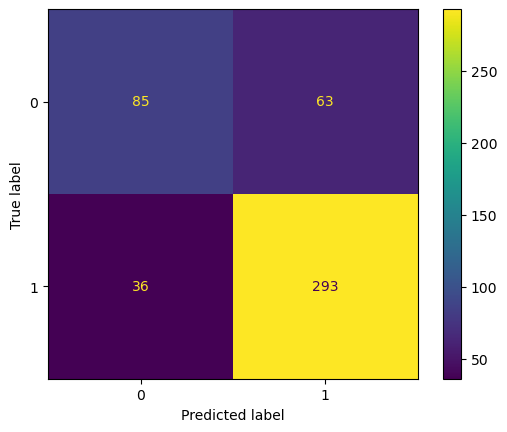

In [109]:
y_pred = c.predict(X_test)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm,
display_labels=c.classes_).plot()


Random Forest Classifier with balanced class weight

 • Out of all prediction, the measure for correctly predicted 0 is 70% and for 1 is 82%
    (Precision)
    
 • Out of all actual 0, the measure for correctly predicted is 57% and for 1 is 89%
    (Recall) As this is imbalanced dataset. We give importance to F1-Score metrics
    
 • F1 Score of 0 is 63%
 
 • F1 Score of 1 is 86%

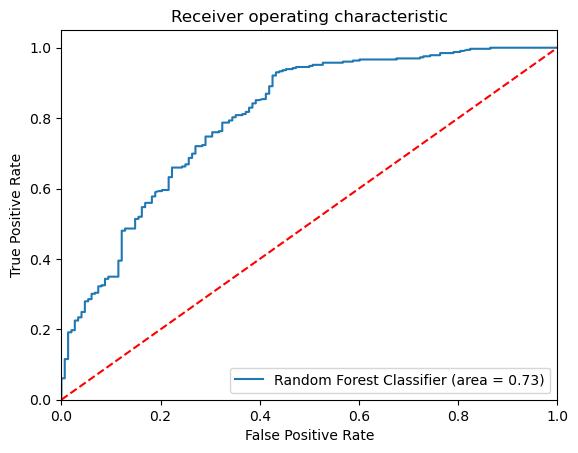

In [112]:
logit_roc_auc=roc_auc_score(y_test,y_pred)
fpr,tpr,thresholds=roc_curve(y_test,c.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr,tpr,label='Random Forest Classifier (area = %0.2f)' %
logit_roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()


• The ROC curve in the image shows that the random forest classifier has an area under
the curve (AUC) of 0.73. This means that the model is able to correctly distinguish
between positive and negative cases 73% of the time, on average

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Params:  {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}
Best Score:  0.8710662040035873

Elapsed Time:  31.200376510620117
              precision    recall  f1-score   support

           0       0.80      0.55      0.65       148
           1       0.82      0.94      0.88       329

    accuracy                           0.82       477
   macro avg       0.81      0.74      0.76       477
weighted avg       0.82      0.82      0.81       477



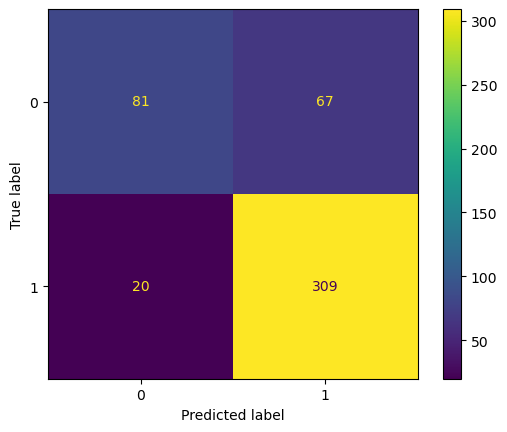

In [114]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay
import time
params = {
 "max_depth": [2, 3, 4],
 "n_estimators": [50, 100, 150, 200],
 # Additional boosting-specific parameters can be added here
 "learning_rate": [0.01, 0.1, 0.2]
}
start_time = time.time()
gradient_boosting = GradientBoostingClassifier()
c = GridSearchCV(estimator=gradient_boosting, param_grid=params,
n_jobs=-1, cv=3, verbose=True, scoring='f1')
c.fit(X_train, y_train)
print("Best Params: ", c.best_params_)
print("Best Score: ", c.best_score_)
elapsed_time = time.time() - start_time
print("\nElapsed Time: ", elapsed_time)
y_pred = c.predict(X_test)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm,
display_labels=c.classes_).plot()

• The model correctly classified 81 instances of class 0 and 309 instances of class 1.
    
• It incorrectly classified 67 instances of class 0 as class 1 (false positives) and 20 instances
of class 1 as class 0 (false negatives).
    
• Best Parameters: The best hyperparameter configuration found through cross-validation is {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}.
    
• Best Score: The model achieved a best score of 0.8710662040035873 (presumably a metric like accuracy or AUC-ROC, but please clarify if it's different).

• Elapsed Time: The fitting process took 31.2 seconds.
    
• Accuracy: The overall model accuracy is  0.82.
    
• Precision and Recall:

• For class 0, precision is  0.80 and recall is 0.55. *For class 1, precision is 0.82 and recall is 0.94.

• F1-Score: The average F1-score across classes is 0.76.